In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (3).zip


In [9]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [10]:
import os
os.listdir()

['.config',
 'archive (3).zip',
 'archive (1).zip',
 'archive.zip',
 'olist_products_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_customers_dataset.csv',
 'archive (2).zip',
 'olist_orders_dataset.csv',
 'product_category_name_translation.csv',
 'olist_order_reviews_dataset.csv',
 'sample_data']

In [11]:
import os

for f in os.listdir():
    print(f)

.config
archive (3).zip
archive (1).zip
archive.zip
olist_products_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_sellers_dataset.csv
olist_customers_dataset.csv
archive (2).zip
olist_orders_dataset.csv
product_category_name_translation.csv
olist_order_reviews_dataset.csv
sample_data


In [12]:
import os
print(os.getcwd())

/content


In [13]:
os.path.exists("olist_orders_dataset.csv")

True

In [14]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [16]:
orders.isnull().sum()

products.isnull().sum()

reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [17]:
orders.duplicated().sum()

items.duplicated().sum()

products.duplicated().sum()

np.int64(0)

In [18]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [19]:
df = items.merge(products,on='product_id')

df = df.merge(
    translation,
    on='product_category_name',
    how='left'
)

df = df.merge(
    orders[['order_id','customer_id','order_purchase_timestamp']],
    on='order_id'
)

df = df.merge(
    customers[['customer_id','customer_state']],
    on='customer_id'
)

In [20]:
df['revenue'] = df['price'] + df['freight_value']

In [21]:
category_sales = (
    df.groupby('product_category_name_english')['revenue']
      .sum()
      .sort_values(ascending=False)
)

category_sales.head()

,revenue
product_category_name_english,
health_beauty,1441248.07
watches_gifts,1305541.61
bed_bath_table,1241681.72
sports_leisure,1156656.48
computers_accessories,1059272.40


In [27]:
monthly_sales = (
    df.groupby(
        df['order_purchase_timestamp'].dt.to_period('M')
    )['revenue']
    .sum()
)

print("Monthly Sales:")
print(monthly_sales)

print("\nTop 5 Months:")
print(monthly_sales.sort_values(ascending=False).head())

Monthly Sales:
order_purchase_timestamp
2016-09        354.75
2016-10      56808.84
2016-12         19.62
2017-01     137188.49
2017-02     286280.62
2017-03     432048.59
2017-04     412422.24
2017-05     586190.95
2017-06     502963.04
2017-07     584971.62
2017-08     668204.60
2017-09     720398.91
2017-10     769312.37
2017-11    1179143.77
2017-12     863547.23
2018-01    1107301.89
2018-02     986908.96
2018-03    1155126.82
2018-04    1159698.04
2018-05    1149781.82
2018-06    1022677.11
2018-07    1058728.03
2018-08    1003308.47
2018-09        166.46
Freq: M, Name: revenue, dtype: float64

Top 5 Months:
order_purchase_timestamp
2017-11    1179143.77
2018-04    1159698.04
2018-03    1155126.82
2018-05    1149781.82
2018-01    1107301.89
Freq: M, Name: revenue, dtype: float64


In [28]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Best Month:", best_month)
print("Revenue:", best_month_sales)

Best Month: 2017-11
Revenue: 1179143.77


In [29]:
state_sales = (
    df.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by State:")
print(state_sales)

print("\nTop 10 States:")
print(state_sales.head(10))

Revenue by State:
customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
PE     322237.69
CE     275606.30
PA     217647.11
MT     186168.96
MA     151171.99
PB     140987.81
MS     135956.67
PI     108132.28
RN     101895.08
AL      96229.40
SE      73032.32
TO      61354.42
RO      57558.02
AM      27835.73
AC      19669.70
AP      16262.80
RR      10064.62
Name: revenue, dtype: float64

Top 10 States:
customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: revenue, dtype: float64


In [30]:
best_state = state_sales.idxmax()
best_state_revenue = state_sales.max()

print("Best State:", best_state)
print("Revenue:", best_state_revenue)

Best State: SP
Revenue: 5921678.12


In [32]:
order_values = (
    df.groupby('order_id')['revenue']
      .sum()
)

aov = order_values.mean()
print(aov)

160.57763809214927


In [33]:
reviews['review_score'].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


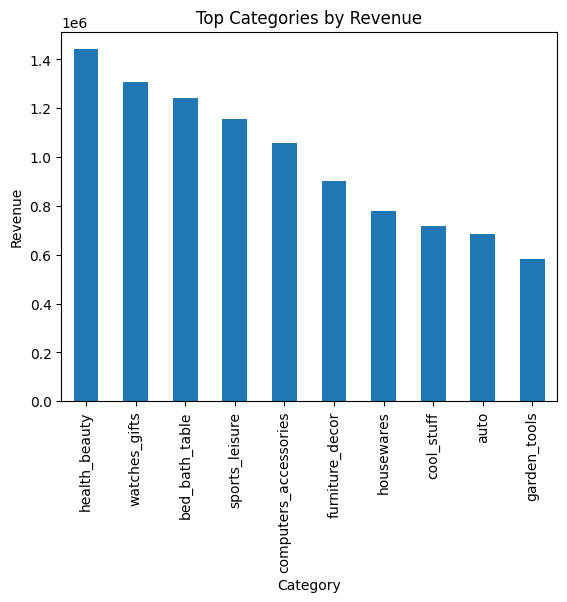

In [34]:
category_sales.head(10).plot(kind='bar')
plt.title('Top Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

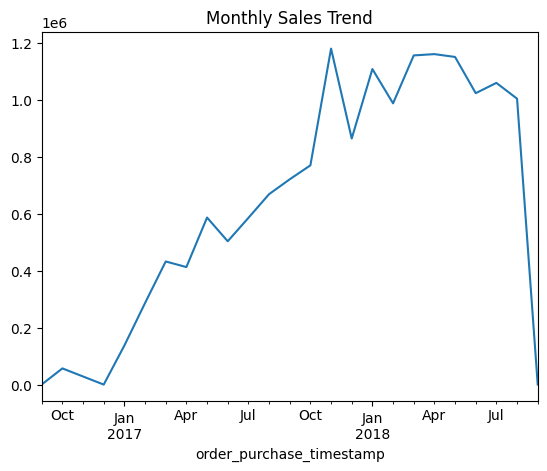

In [35]:
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.show()

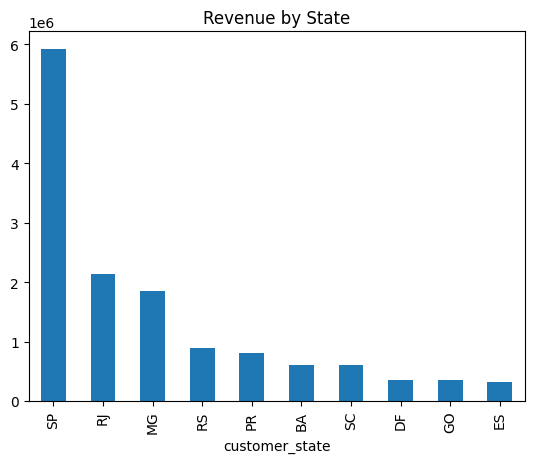

In [36]:
state_sales.head(10).plot(kind='bar')
plt.title('Revenue by State')
plt.show()

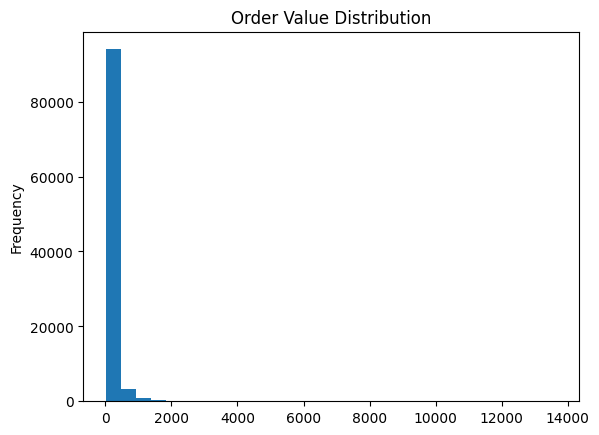

In [37]:
order_values.plot(kind='hist', bins=30)
plt.title('Order Value Distribution')
plt.show()

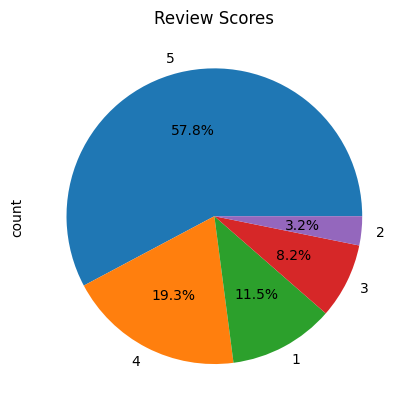

In [38]:
reviews['review_score'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Review Scores')
plt.show()

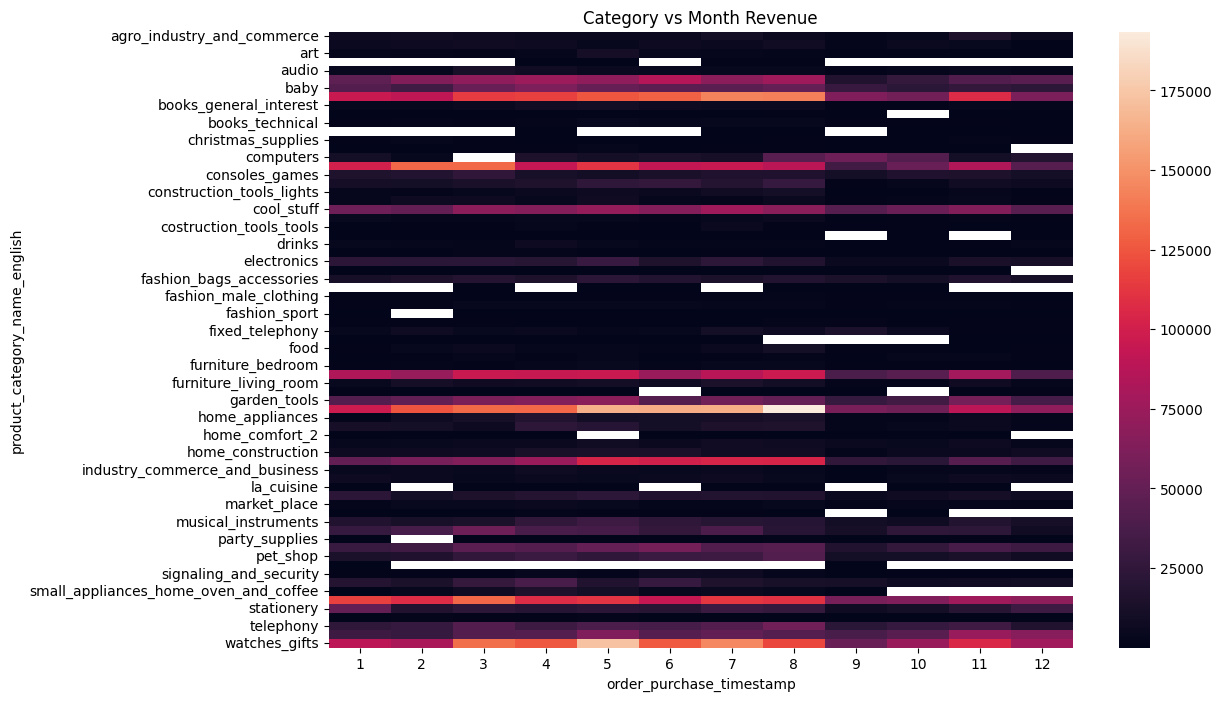

In [39]:
heatmap_data = pd.pivot_table(
    df,
    values='revenue',
    index='product_category_name_english',
    columns=df['order_purchase_timestamp'].dt.month,
    aggfunc='sum'
)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data)
plt.title('Category vs Month Revenue')
plt.show()

In [41]:
total_revenue = df['revenue'].sum()

total_orders = df['order_id'].nunique()

avg_order_value = order_values.mean()

top_category = category_sales.idxmax()

best_state = state_sales.idxmax()

print("===== DASHBOARD KPIs =====")
print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))
print("Top Category:", top_category)
print("Best State:", best_state)

===== DASHBOARD KPIs =====
Total Revenue: 15843553.24
Total Orders: 98666
Average Order Value: 160.58
Top Category: health_beauty
Best State: SP


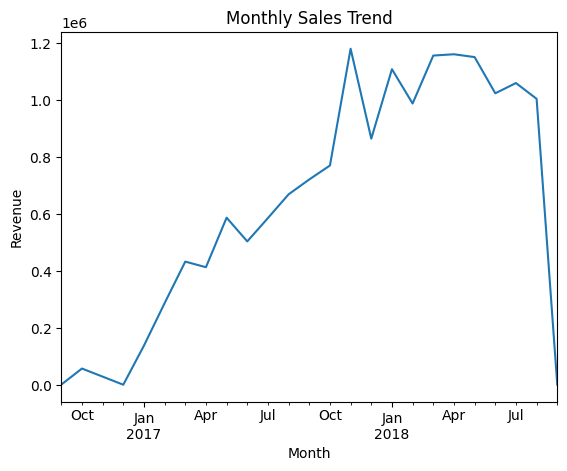

In [42]:
monthly_sales.plot(kind='line')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

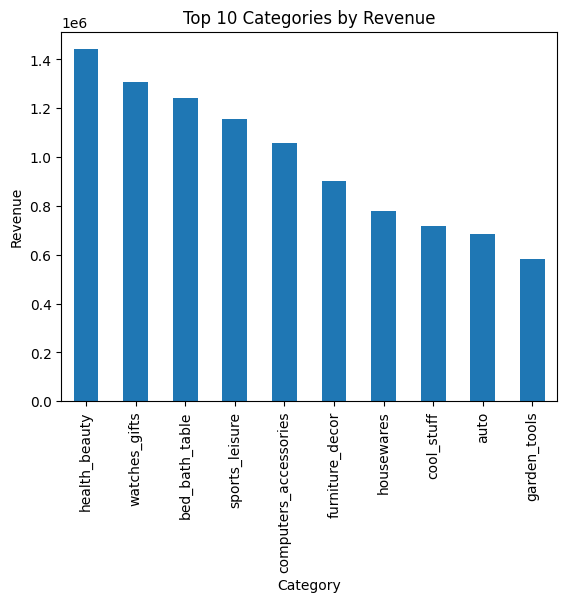

In [43]:
category_sales.head(10).plot(kind='bar')

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

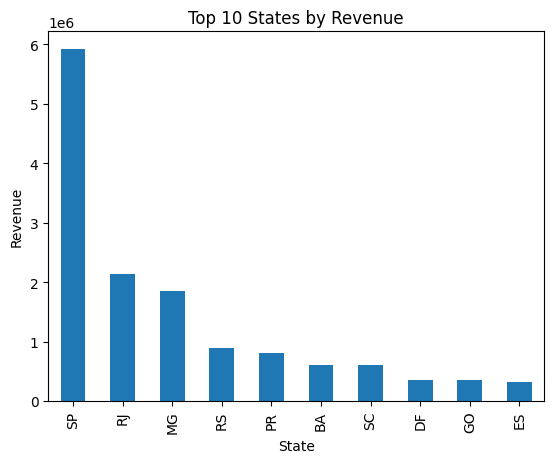

In [44]:
state_sales.head(10).plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

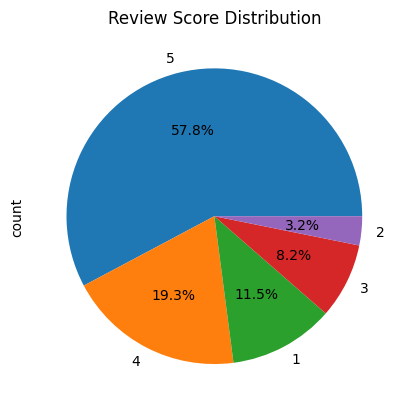

In [45]:
reviews['review_score'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Review Score Distribution')

plt.show()

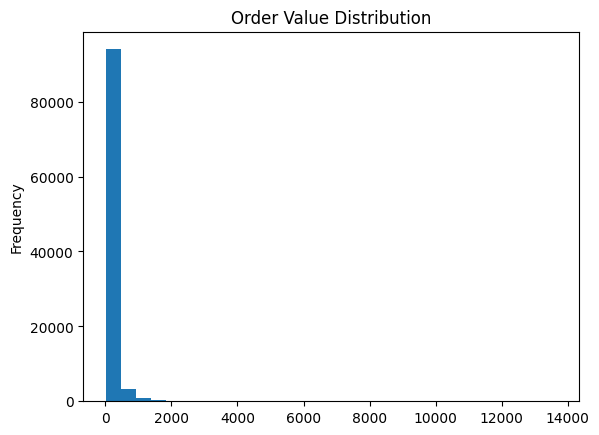

In [46]:
order_values.plot(
    kind='hist',
    bins=30
)

plt.title('Order Value Distribution')

plt.show()

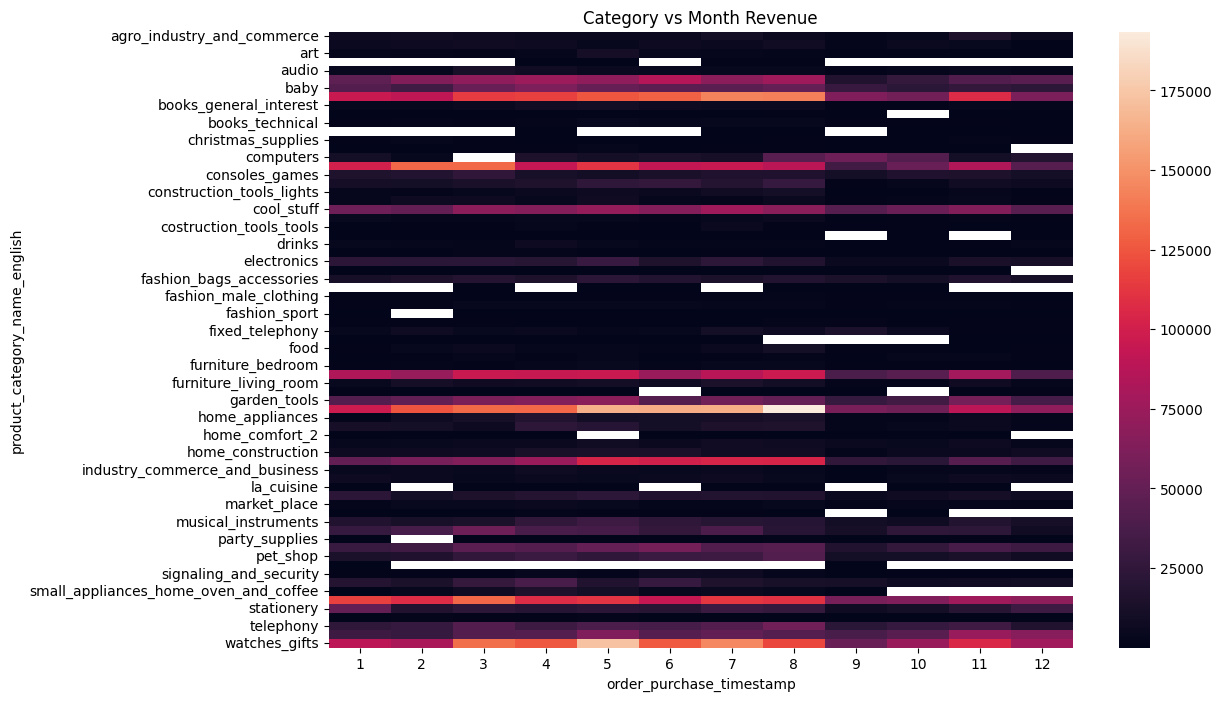

In [47]:
heatmap_data = pd.pivot_table(
    df,
    values='revenue',
    index='product_category_name_english',
    columns=df['order_purchase_timestamp'].dt.month,
    aggfunc='sum'
)

plt.figure(figsize=(12,8))

sns.heatmap(heatmap_data)

plt.title('Category vs Month Revenue')

plt.show()

# Business Insights

## Insight 1
Health & Beauty products generated the highest revenue among all categories.

Recommendation:
Increase inventory and marketing campaigns for Health & Beauty products.

## Insight 2
Sales reached their peak during November.

Recommendation:
Launch festive promotions and discount campaigns during November.

## Insight 3
São Paulo contributed the highest revenue.

Recommendation:
Focus regional advertising and logistics investments in São Paulo.

## Insight 4
Average Order Value is relatively high.

Recommendation:
Introduce product bundles and upselling strategies.

## Insight 5
Most customers provided 5-star ratings.

Recommendation:
Maintain customer service quality and delivery efficiency.

In [49]:
print("Most Surprising Finding:")
print(
    "Customer satisfaction remained very high, "
    "with most reviews receiving 5 stars despite "
    "the large volume of transactions."
)

Most Surprising Finding:
Customer satisfaction remained very high, with most reviews receiving 5 stars despite the large volume of transactions.
